# Tutorial 3: Tuning and training models

Once all of the data is QC, processed, and ingested, the real fun begins. This tutorial details, first, how to train a MuTopia model. 
Then, we'll go over more rigorous hyperparameter tuning techniques to ensure a better fit to your data.


## Prerequisites

Before starting this tutorial, ensure you have:
- MuTopia package installed
- Download the pre-compiled data to the `tutorial_data` directory

## 1. Training a MuTopia model

### 1.1 Preparing and loading the data

The first step in preparing the data for model training is to split train and test sets. This is easiest using the CLI as below. I like to use chromosome 1 as the test set and train on everything else.

In [1]:
!gtensor split tutorial_data/Liver.nc chr1

Writing samples: 100%|████████████████████████████████████████████| 185/185 [00:28<00:00,  6.48it/s]


Import `MuTopia`:

In [1]:
import mutopia.analysis as mu

Now, you can use `gt.lazy_load` or `gt.load_dataset(..., with_samples=False)` to load the dataset, while keeping the samples on-disk:

In [2]:
train = mu.gt.lazy_load("tutorial_data/Liver.train.nc")
test = mu.gt.lazy_load("tutorial_data/Liver.test.nc")

### 1.2 Instantiating the model

Now, we can instantiate a model. Make sure to use the correct data modality - in this case `{dataset}.modality()`, and make a `TopographyModel` object. 

There are a ton of configurable parameters, but the main ones you'll often use are:
* `num_components` - how many processes to fit.
* `init_components` - a list of signatures to initialize the model with.
* `locus_subsample` - to what degree to subsample the loci in the dataset for each update.
* `batch_subsample` - to what degree to subsample the samples in the dataset. I shoot for a batch size of at least 32.
* `threads` - number of threads to devote to update calculations.

#### Rules of thumb for training models
* Always use some form of subsampling as batch training leads to overfitting. - `locus_subsample` works by far the best.
* Make sure your iteration time is below 30 seconds by adjusting `threads`, `locus_subsampling`, and `batch_subsample`. Iteration time is proportional to the number of mutations used for the parameter updates. Using more mutations has diminishing returns over the number of steps you perform. I usually shoot for about 20 seconds per iteration to start (iteration time decreases as the model converges as well).
* Train until convergence (by not setting `num_epochs`) - MuTopia will automatically stop the model when it detects it has converged. 
* For really small datasets, use `init_components` to specify starting points for the spectra. You can list COSMIC components like: `["SBS1", "SBS3", ...]`.

In [ ]:
SBS_model = mu.make_model_cls(train)

model = SBS_model(
    num_components = 15,
    seed=42,
    locus_subsample=1/8,
    threads=5,
    eval_every=1, # just for illustration purposes; use a larger value in practice or your train time will increase
    num_epochs=10, # just for illustration purposes; use a larger value in practice (like 1000 just to be safe)
)

INFO: Mutopia:JIT-compiling model operations ...


### 1.3 Training

Now, we are ready to train. Supply the train and the test sets to the `fit` method:

In [5]:
model = model.fit(train, test)

INFO: Mutopia:Initializing model parameters and transformations...
INFO: Mutopia:Found strand features:
	GeneStrand, ReplicationStrand
INFO: Mutopia:Found mesoscale features:[]
INFO: Mutopia:Found locus features:
	ATACAccessible, DNase, GeneExpression, GenePosition,
	H3K27ac, H3K27me3, H3K36me3, H3K4me1,
	H3K4me3, H3K9me3, NucleotideRatio, RepliseqG1b,
	RepliseqG2, RepliseqS1, RepliseqS2, RepliseqS3,
	RepliseqS4
INFO: Mutopia:Validating datasets...
INFO: Mutopia:Found n=185 training samples across 1 datasets.
INFO: Mutopia:Preprocessing training datasets...
INFO: Mutopia:Preprocessing testing datasets...
INFO: Mutopia:Using SVI.
INFO: Mutopia:Training model with 5 threads.
INFO: Mutopia:The first few epochs take longer as things get warmed up -
	expect the time per epoch to decrease about 4-fold.
INFO: Mutopia:Model will stop training if no improvement in the last 50 epochs.
INFO: Mutopia:Training usually coverges much sooner than 10 epochs.
Epoch: 10/10 |██████████| [01:48<00:00, 10.8

For score, higher is better - Don't worry about the "low" score values this is mostly reflective of the sparse nature of the data.

You can save a model to disk using the `model.save` method:

In [6]:
model.save("tutorial_data/trained_model.pkl")

Alternatively, you can perform the same training from the CLI using the command below:

**Note:** Make sure to use the `--lazy` flag! 

In [7]:
!topo-model train \
    -ds tutorial_data/Liver.train.nc tutorial_data/Liver.test.nc \
    -k 15 \
    -o tutorial_data/cli_trained_model.pkl \
    -@ 5 \
    --seed 42 \
    --locus-subsample 0.125 \
    --eval-every 1 \
    --num-epochs 10 \
    --lazy

Training model with parameters: 
Parameter              Value
---------------------  ---------
num_components         15
threads                5
seed                   42
locus_subsample        0.125
eval_every             1
num_epochs             10
locus_model_type       gbt
use_groups             True
add_corpus_intercepts  False
empirical_bayes        True
stop_condition         50
test_chroms            ('chr1',)
INFO: Mutopia:Training with 1 dataset pairs
INFO: Mutopia:JIT-compiling model operations ...
INFO: Mutopia:Initializing model parameters and transformations...
INFO: Mutopia:Found strand features:
	GeneStrand, ReplicationStrand
INFO: Mutopia:Found mesoscale features:[]
INFO: Mutopia:Found locus features:
	ATACAccessible, DNase, GeneExpression, GenePosition,
	H3K27ac, H3K27me3, H3K36me3, H3K4me1,
	H3K4me3, H3K9me3, NucleotideRatio, RepliseqG1b,
	RepliseqG2, RepliseqS1, RepliseqS2, RepliseqS3,
	RepliseqS4
INFO: Mutopia:Validating datasets...
INFO: Mutopia:Found n=185 train

## 2. Model hyperparameter tuning

Hyperparameter optimization provides a convenient way to launch many trial trainings to find the best hyperparameter configurations among them. 

Trials are organized under a "study". Create a study using the `topo-model study create` command. The most important parameters to specify are the study path ("studies/liver/01"), the datasets (you can provide multiple train/test pairs by providing multiple `-ds` flags), the minimum and maximum number of components to try out (`-min` and `-max`, respectively), `--save-model`, which will write models to disk under `studies/<study_name>` when trials complete, and whatever other parameter values you would like to fix across trials (in this case, just the locus subsample rate, `-lsub`).

**Optional:** By adding `-e` flags (e.g. `-e`, `-ee`, etc.) you can increase how "extensive" the hyperparameter tuning is. For no `e`, MuTopia only tunes the number of components. For one `e`, MuTopia tunes the next most important hyperparameters, and so on. If you have the time, one `-e` is a good balance.

In [8]:
!topo-model study create \
    "studies/liver/01" \
    -ds tutorial_data/Liver.train.nc tutorial_data/Liver.test.nc \
    -min 5 -max 20 \
    --save-model \
    -lsub 0.125

Fixing parameters: 
Parameter              Value
---------------------  ---------
locus_subsample        0.125
init_components        ()
fix_components         ()
pi_prior               1.0
locus_model_type       gbt
use_groups             False
add_corpus_intercepts  False
empirical_bayes        True
stop_condition         50
num_epochs             2000
test_chroms            ('chr1',)
[I 2025-10-20 10:14:26,742] Using an existing study with name 'mutopia_tuning_study' instead of creating a new one.
Successfully created optimization study: studies/liver/01


Now, you can launch trials from the CLI, which makes this easy to parallelize using slurm jobs on a server. Just refer the `study_name` using the path and your runtime options (laziness and number of threads), and you're off!

In [9]:
!topo-model study run "studies/liver/01" --lazy -@ 5

INFO: Mutopia:JIT-compiling model operations ...
INFO: Mutopia:Running trial 1 with params:
	num_components: 16
INFO: Mutopia:Initializing model parameters and transformations...
INFO: Mutopia:Found strand features:
	GeneStrand, ReplicationStrand
INFO: Mutopia:Found mesoscale features:[]
INFO: Mutopia:Found locus features:
	ATACAccessible, DNase, GeneExpression, GenePosition,
	H3K27ac, H3K27me3, H3K36me3, H3K4me1,
	H3K4me3, H3K9me3, NucleotideRatio, RepliseqG1b,
	RepliseqG2, RepliseqS1, RepliseqS2, RepliseqS3,
	RepliseqS4
INFO: Mutopia:Validating datasets...
INFO: Mutopia:Found n=185 training samples across 1 datasets.
INFO: Mutopia:Preprocessing training datasets...
INFO: Mutopia:Preprocessing testing datasets...
INFO: Mutopia:Using SVI.
INFO: Mutopia:Training model with 5 threads.
INFO: Mutopia:The first few epochs take longer as things get warmed up -
	expect the time per epoch to decrease about 4-fold.
INFO: Mutopia:Model will stop training if no improvement in the last 50 epochs.


I usually use this wrapper script to launch job arrays on SLURM servers:
```bash
#!/bin/bash
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=5
#SBATCH --mem-per-cpu=500
#SBATCH --time=05:00:00
#SBATCH --output=logs/%x/%j_%a.log

study_name=${SLURM_JOB_NAME}
time_limit=$((60*5 - 10)) # in minutes

echo "Running trial for study: ${study_name}, time limit: ${time_limit} minutes"
topo-model study run ${study_name} -@ 5 --lazy --time-limit ${time_limit}
```

Save this wrapper as `run-trials.sh`. Then, you can launch array jobs for different studies using:

```bash
$ study_path="studies/liver/01"
$ sbatch --job-name=$study_path --array=1-5%20 run-trials.sh
```

Start slow, launching a few jobs to see what sort of memory you require, then scale up! Make sure to adjust the job time if needed.

To look at the results of a study, you can use `topo-model study summary`. You can check out the results by referring to a study via it's path:

In [14]:
!topo-model study summary "studies/liver/01" -o results.csv
!head -n 3 results.csv

Results saved to: results.csv
number,value,state,user_attrs_model_path,num_components
0,0.0023026805200607736,COMPLETE,studies/liver/01/trial=0.pkl,15
1,,RUNNING,studies/liver/01/trial=1.pkl,16


Obviously, this is more exciting if you've run more trials. I included the results from a full tuning run on the the tutorial data to demonstrate how to choose the best model.

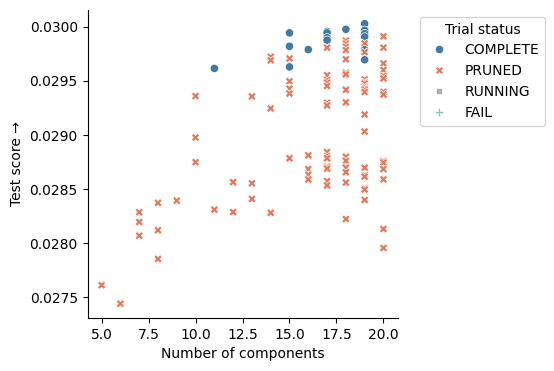

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.read_csv("tutorial_data/study_results.csv")
_, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(
    data=results,
    x="num_components",
    y="value",
    style="state",
    hue="state",
    palette=mu.pl.categorical_palette,
)
ax.legend(
    title="Trial status",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
ax.set(
    xlabel="Number of components",
    ylabel="Test score \u2192",
)
sns.despine()

In [12]:
results.head(10)

,number,value,state,user_attrs_model_path,num_components
0,93,0.030026,COMPLETE,studies/liver/01/trial=93.pkl,19
1,151,0.029974,COMPLETE,studies/liver/01/trial=151.pkl,18
2,73,0.029966,COMPLETE,studies/liver/01/trial=73.pkl,19
3,130,0.029955,COMPLETE,studies/liver/01/trial=130.pkl,17
4,126,0.029942,COMPLETE,studies/liver/01/trial=126.pkl,17
5,110,0.029941,COMPLETE,studies/liver/01/trial=110.pkl,15
6,85,0.029934,COMPLETE,studies/liver/01/trial=85.pkl,19
7,137,0.029909,PRUNED,NaN,20
8,97,0.029904,COMPLETE,studies/liver/01/trial=97.pkl,19
9,114,0.029896,COMPLETE,studies/liver/01/trial=114.pkl,17


You can select the best model using the "elbow" method (`value` versus the `num_components`), and load it from the `user_attrs_model_path` column. In this case, you should choose the model with the least topics that achieves close to the maximum score. Above, the best model with 15 components meets these criteria.

**Note:** The "Pruned" models were determined by the optimization engine to be under-performing, and so their execution was terminated to save computational resources!

#### MORE IMPORTANT NOTE: HIGHER SCORES ARE BETTER!


If a promising model failed to save for some reason (early termination, memory overflow, etc.) you can re-train it with the same parameters using:

In [15]:
!topo-model study retrain "studies/liver/01" 0 "best_model.pkl" --lazy -@ 5

INFO: Mutopia:JIT-compiling model operations ...
INFO: Mutopia:Initializing model parameters and transformations...
INFO: Mutopia:Found strand features:
	GeneStrand, ReplicationStrand
INFO: Mutopia:Found mesoscale features:[]
INFO: Mutopia:Found locus features:
	ATACAccessible, DNase, GeneExpression, GenePosition,
	H3K27ac, H3K27me3, H3K36me3, H3K4me1,
	H3K4me3, H3K9me3, NucleotideRatio, RepliseqG1b,
	RepliseqG2, RepliseqS1, RepliseqS2, RepliseqS3,
	RepliseqS4
INFO: Mutopia:Validating datasets...
INFO: Mutopia:Found n=185 training samples across 1 datasets.
INFO: Mutopia:Preprocessing training datasets...
INFO: Mutopia:Preprocessing testing datasets...
INFO: Mutopia:Using SVI.
INFO: Mutopia:Training model with 5 threads.
INFO: Mutopia:The first few epochs take longer as things get warmed up -
	expect the time per epoch to decrease about 4-fold.
INFO: Mutopia:Model will stop training if no improvement in the last 50 epochs.
INFO: Mutopia:Training usually coverges much sooner than 2000 e

To investigate model performance more thoroughly, you can load the `Optuna` study directly using the python API:

In [16]:
study, *_ = mu.tuning.load_study("studies/liver/01")
study